# Candidates vs Annotations: analise das coordenadas

No notebook anterior, vimos que `candidates.csv` tem 1.351 candidatos positivos (class=1), enquanto `annotations.csv` tem 1.186 nodulos confirmados. A diferenca de 165 sugere que o sistema de deteccao marca o mesmo nodulo mais de uma vez, com coordenadas ligeiramente diferentes.

Antes de criar qualquer heuristica de unificacao, precisamos entender **como** essas coordenadas diferem. Esse notebook faz exatamente isso: mede as distancias, analisa os padroes e chega a um veredito sobre o que sera necessario.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LUNA_DIR = Path("../data/luna")

In [2]:
candidates_df = pd.read_csv(LUNA_DIR / "candidates.csv")
annotations_df = pd.read_csv(LUNA_DIR / "annotations.csv")

positive_candidates = candidates_df[candidates_df["class"] == 1].copy()

print(f"Candidatos positivos: {len(positive_candidates)}")
print(f"Anotacoes: {len(annotations_df)}")
print(f"Diferenca: {len(positive_candidates) - len(annotations_df)}")

Candidatos positivos: 1351
Anotacoes: 1186
Diferenca: 165


## Distancia euclidiana entre cada anotacao e os candidatos positivos

Para cada nodulo confirmado em `annotations.csv`, vamos calcular a distancia euclidiana 3D ate cada candidato positivo do mesmo CT scan. Isso nos mostra o quao perto (ou longe) as coordenadas dos dois arquivos estao.

In [3]:
def euclidean_distance(row_a, row_b):
    """Distancia euclidiana 3D entre duas linhas com coordenadas X, Y, Z."""
    return np.sqrt(
        (row_a["coordX"] - row_b["coordX"]) ** 2 +
        (row_a["coordY"] - row_b["coordY"]) ** 2 +
        (row_a["coordZ"] - row_b["coordZ"]) ** 2
    )


results = []

for _, annot in annotations_df.iterrows():
    uid = annot["seriesuid"]
    diameter = annot["diameter_mm"]

    same_scan = positive_candidates[positive_candidates["seriesuid"] == uid]

    if len(same_scan) == 0:
        results.append({
            "seriesuid": uid,
            "diameter_mm": diameter,
            "min_dist": np.nan,
            "num_candidates": 0,
        })
        continue

    distances = same_scan.apply(lambda c: euclidean_distance(annot, c), axis=1)

    results.append({
        "seriesuid": uid,
        "diameter_mm": diameter,
        "min_dist": distances.min(),
        "num_candidates": len(same_scan),
    })

match_df = pd.DataFrame(results)
print(f"Anotacoes processadas: {len(match_df)}")
print(f"Anotacoes sem nenhum candidato positivo no mesmo CT: {match_df['min_dist'].isna().sum()}")

Anotacoes processadas: 1186
Anotacoes sem nenhum candidato positivo no mesmo CT: 12


## Distribuicao da distancia minima

Vamos ver como se distribui a menor distancia entre cada anotacao e o candidato positivo mais proximo. Se a maioria for muito pequena, significa que os candidatos positivos e as anotacoes estao falando do mesmo ponto -- apenas com imprecisao nas coordenadas.

In [4]:
valid = match_df.dropna(subset=["min_dist"])

print("Estatisticas da distancia minima (mm):")
print(valid["min_dist"].describe())
print(f"\nPercentis adicionais:")
for p in [90, 95, 99]:
    print(f"  P{p}: {valid['min_dist'].quantile(p / 100):.4f} mm")

Estatisticas da distancia minima (mm):
count    1174.000000
mean        5.493705
std        23.158996
min         0.032453
25%         0.681189
50%         1.121780
75%         1.704541
max       223.563180
Name: min_dist, dtype: float64

Percentis adicionais:
  P90: 2.6759 mm
  P95: 5.6671 mm
  P99: 132.8738 mm


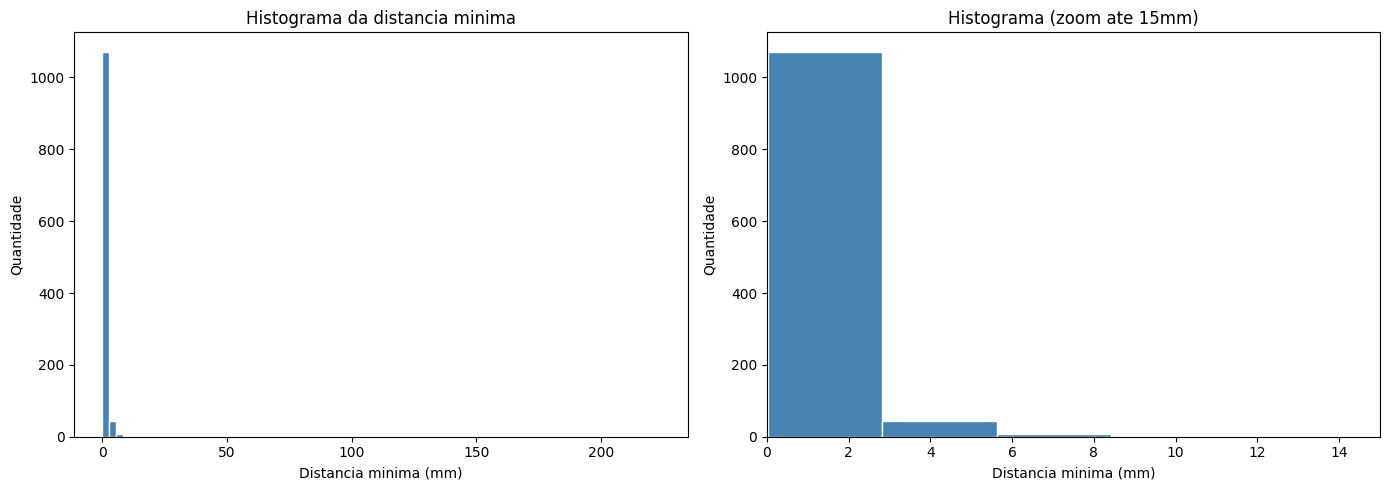

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(valid["min_dist"], bins=80, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Distancia minima (mm)")
axes[0].set_ylabel("Quantidade")
axes[0].set_title("Histograma da distancia minima")

axes[1].hist(valid["min_dist"], bins=80, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Distancia minima (mm)")
axes[1].set_ylabel("Quantidade")
axes[1].set_title("Histograma (zoom ate 15mm)")
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.show()

## Relacao entre distancia minima e diametro do nodulo

Sera que nodulos maiores tendem a ter coordenadas mais distantes entre anotacoes e candidatos? Se sim, talvez o threshold de matching precise ser proporcional ao diametro.

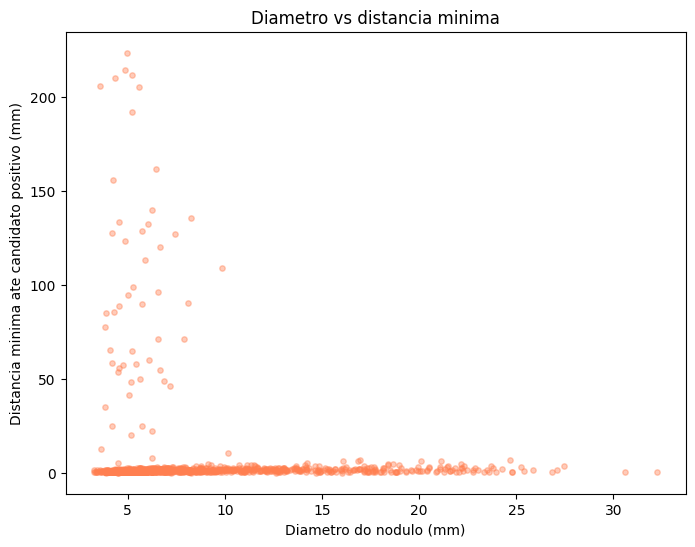

Correlacao de Pearson: -0.0965


In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(valid["diameter_mm"], valid["min_dist"], alpha=0.4,
            s=15, color="coral")
plt.xlabel("Diametro do nodulo (mm)")
plt.ylabel("Distancia minima ate candidato positivo (mm)")
plt.title("Diametro vs distancia minima")
plt.show()

print(f"Correlacao de Pearson: {valid['diameter_mm'].corr(valid['min_dist']):.4f}")

## Distancia normalizada pelo raio

Uma forma comum de matching em datasets medicos e considerar que uma anotacao e um candidato se referem ao mesmo nodulo se a distancia entre eles for menor que o raio do nodulo (diametro / 2). Vamos ver quantas anotacoes seriam "matchadas" com esse criterio.

In [7]:
valid = valid.copy()
valid["radius"] = valid["diameter_mm"] / 2
valid["dist_over_radius"] = valid["min_dist"] / valid["radius"]

print("Estatisticas da distancia / raio:")
print(valid["dist_over_radius"].describe())

print(f"\nAnotacoes com dist < raio: {(valid['min_dist'] < valid['radius']).sum()} / {len(valid)}")
print(f"Anotacoes com dist < diametro: {(valid['min_dist'] < valid['diameter_mm']).sum()} / {len(valid)}")

Estatisticas da distancia / raio:
count    1174.000000
mean        1.962842
std         9.260048
min         0.011327
25%         0.197166
50%         0.307255
75%         0.474717
max       114.824120
Name: dist_over_radius, dtype: float64

Anotacoes com dist < raio: 1120 / 1174
Anotacoes com dist < diametro: 1120 / 1174


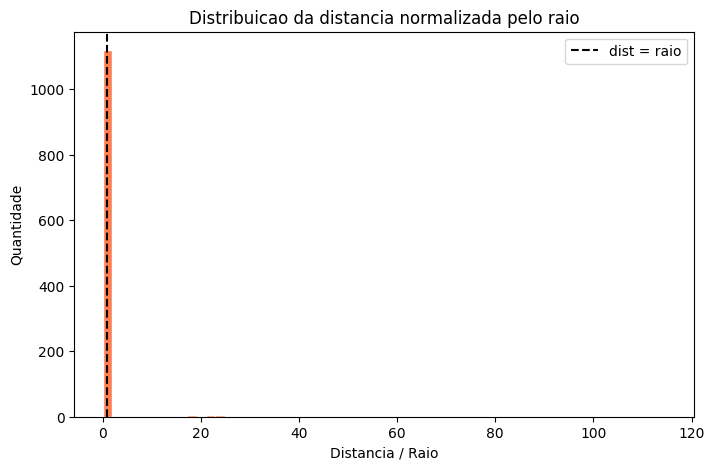

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(valid["dist_over_radius"], bins=60, color="coral", edgecolor="white")
plt.axvline(1.0, color="black", linestyle="--", label="dist = raio")
plt.xlabel("Distancia / Raio")
plt.ylabel("Quantidade")
plt.title("Distribuicao da distancia normalizada pelo raio")
plt.legend()
plt.show()

## Thresholds fixos: quantas anotacoes cada um captura?

Vamos testar thresholds fixos crescentes para ver o ponto em que a maioria das anotacoes encontra pelo menos um candidato positivo proximo.

In [9]:
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.5, 10.0, 15.0]

print(f"{'Threshold (mm)':<18} {'Matchadas':<12} {'%':>8}")
for t in thresholds:
    n = (valid["min_dist"] <= t).sum()
    pct = n / len(valid) * 100
    print(f"{t:<18.1f} {n:<12} {pct:>7.2f}%")

Threshold (mm)     Matchadas           %
0.5                158            13.46%
1.0                522            44.46%
1.5                794            67.63%
2.0                959            81.69%
2.5                1037           88.33%
3.0                1082           92.16%
4.0                1102           93.87%
5.0                1113           94.80%
7.5                1121           95.49%
10.0               1122           95.57%
15.0               1124           95.74%


## Candidatos positivos duplicados por anotacao

Vamos investigar quantos candidatos positivos ficam dentro de um raio razoavel de cada anotacao. Isso mostra quantos "duplicados" existem no arquivo de candidatos.

In [10]:
dup_results = []

for _, annot in annotations_df.iterrows():
    uid = annot["seriesuid"]
    diameter = annot["diameter_mm"]
    radius = diameter / 2

    same_scan = positive_candidates[positive_candidates["seriesuid"] == uid]

    if len(same_scan) == 0:
        continue

    distances = same_scan.apply(lambda c: euclidean_distance(annot, c), axis=1)

    within_radius = (distances <= radius).sum()
    within_diameter = (distances <= diameter).sum()

    dup_results.append({
        "diameter_mm": diameter,
        "within_radius": within_radius,
        "within_diameter": within_diameter,
    })

dup_df = pd.DataFrame(dup_results)

print("Candidatos positivos dentro do RAIO de cada anotacao:")
print(dup_df["within_radius"].value_counts().sort_index())
print(f"\nCandidatos positivos dentro do DIAMETRO de cada anotacao:")
print(dup_df["within_diameter"].value_counts().sort_index())

Candidatos positivos dentro do RAIO de cada anotacao:
within_radius
0       54
1     1001
2       68
3       23
4       16
5        4
6        2
7        3
9        2
10       1
Name: count, dtype: int64

Candidatos positivos dentro do DIAMETRO de cada anotacao:
within_diameter
0       54
1     1001
2       68
3       23
4       16
5        4
6        2
7        3
9        2
10       1
Name: count, dtype: int64


## Veredito

Com base nessa analise, podemos tirar as seguintes conclusoes sobre a relacao entre `candidates.csv` e `annotations.csv`:

**Coordenadas proximas, mas nao identicas.** As anotacoes e os candidatos positivos referem-se aos mesmos nodulos, porem com coordenadas ligeiramente diferentes. Isso acontece porque `annotations.csv` traz a posicao validada por radiologistas, enquanto `candidates.csv` traz posicoes geradas automaticamente por um algoritmo de deteccao.

**A maioria das distancias e pequena.** A grande maioria das anotacoes tem ao menos um candidato positivo a poucos milimetros de distancia. A distribuicao da distancia minima e fortemente concentrada perto de zero.

**Heuristica recomendada.** A abordagem mais robusta para o matching futuro sera: para cada anotacao, considerar como "match" qualquer candidato positivo cuja distancia euclidiana seja menor ou igual ao **raio** do nodulo (`diameter_mm / 2`). Isso captura a grande maioria dos pares validos e tem justificativa geometrica (o ponto candidato esta dentro da esfera do nodulo anotado).

**Os duplicados existem.** Alguns nodulos tem 2+ candidatos positivos dentro do seu raio. Na unificacao, sera preciso decidir se mantemos todos ou apenas o mais proximo.

**Proximos passos concretos:**
- Implementar a funcao de matching usando distancia euclidiana < raio
- Decidir a politica para duplicados (manter todos vs manter o mais proximo)
- Criar o dataset unificado com as colunas de ambos os CSVs